In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Deep Learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F

# Text processing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight


In [2]:
# Indonesian text preprocessing
import nltk
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
except:
    pass

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    SASTRAWI_AVAILABLE = True
except ImportError:
    SASTRAWI_AVAILABLE = False
    print("Warning: Sastrawi not available. Install with: pip install Sastrawi")

# Set device for training (CPU optimized for your Ryzen 7 5700U)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [4]:
class IndonesianEmotionClassifier:
    def __init__(self):
        self.emotion_mapping = {
            0: 'Anger', 1: 'Fear', 2: 'Joy', 3: 'Neutral',
            4: 'Proud', 5: 'Sadness', 6: 'Surprise', 7: 'Trust'
        }
        
        # Initialize Indonesian text processors if available
        if SASTRAWI_AVAILABLE:
            self.stemmer = StemmerFactory().create_stemmer()
            self.stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
        
        self.vectorizers = {}
        self.models = {}
        self.best_model = None
        
    def load_data(self, df):
        """Load and prepare the dataset"""
        self.df = df.copy()
        self.df['emotion_label'] = self.df['emotion'].map(self.emotion_mapping)
        return self.df
    
    def exploratory_data_analysis(self):
        """Comprehensive EDA for the dataset"""
        print("=" * 50)
        print("EXPLORATORY DATA ANALYSIS")
        print("=" * 50)
        
        # Basic statistics
        print("\n1. Dataset Overview:")
        print(f"Total samples: {len(self.df)}")
        print(f"Text columns: {self.df['text'].dtype}")
        print(f"Duration range: {self.df['durasi'].min():.2f} - {self.df['durasi'].max():.2f} seconds")
        
        # Emotion distribution
        print("\n2. Emotion Distribution:")
        emotion_counts = self.df['emotion'].value_counts().sort_index()
        for emotion_id, count in emotion_counts.items():
            emotion_name = self.emotion_mapping[emotion_id]
            percentage = (count / len(self.df)) * 100
            print(f"   {emotion_name} ({emotion_id}): {count} samples ({percentage:.1f}%)")
        
        # Check for class imbalance
        max_count = emotion_counts.max()
        min_count = emotion_counts.min()
        imbalance_ratio = max_count / min_count
        print(f"\n   Class imbalance ratio: {imbalance_ratio:.2f}")
        if imbalance_ratio > 3:
            print("   ⚠️ Significant class imbalance detected!")
        
        # Text length analysis
        self.df['text_length'] = self.df['text'].str.len()
        self.df['word_count'] = self.df['text'].str.split().str.len()
        
        print("\n3. Text Statistics:")
        print(f"   Average text length: {self.df['text_length'].mean():.1f} characters")
        print(f"   Average word count: {self.df['word_count'].mean():.1f} words")
        print(f"   Text length range: {self.df['text_length'].min()} - {self.df['text_length'].max()}")
        
        # Duration vs emotion analysis
        print("\n4. Duration Analysis by Emotion:")
        duration_stats = self.df.groupby('emotion_label')['durasi'].agg(['mean', 'std', 'min', 'max'])
        for emotion, stats in duration_stats.iterrows():
            print(f"   {emotion}: avg={stats['mean']:.2f}s (±{stats['std']:.2f})")
        
        # Create visualizations
        self.create_eda_visualizations()
        
        return self.df.describe()
    
    def create_eda_visualizations(self):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Emotion distribution
        emotion_counts = self.df['emotion'].value_counts().sort_index()
        emotion_labels = [self.emotion_mapping[i] for i in emotion_counts.index]
        axes[0,0].bar(emotion_labels, emotion_counts.values, color='skyblue')
        axes[0,0].set_title('Emotion Distribution')
        axes[0,0].set_xlabel('Emotion')
        axes[0,0].set_ylabel('Count')
        axes[0,0].tick_params(axis='x', rotation=45)
        
        # 2. Text length distribution
        axes[0,1].hist(self.df['text_length'], bins=30, alpha=0.7, color='lightgreen')
        axes[0,1].set_title('Text Length Distribution')
        axes[0,1].set_xlabel('Characters')
        axes[0,1].set_ylabel('Frequency')
        
        # 3. Word count distribution
        axes[0,2].hist(self.df['word_count'], bins=30, alpha=0.7, color='salmon')
        axes[0,2].set_title('Word Count Distribution')
        axes[0,2].set_xlabel('Words')
        axes[0,2].set_ylabel('Frequency')
        
        # 4. Duration vs Emotion boxplot
        emotion_labels_full = [self.emotion_mapping[e] for e in self.df['emotion']]
        unique_emotions = sorted(set(emotion_labels_full))
        duration_by_emotion = [self.df[self.df['emotion'] == i]['durasi'].values 
                              for i in range(len(unique_emotions))]
        axes[1,0].boxplot(duration_by_emotion, labels=unique_emotions)
        axes[1,0].set_title('Duration by Emotion')
        axes[1,0].set_xlabel('Emotion')
        axes[1,0].set_ylabel('Duration (seconds)')
        axes[1,0].tick_params(axis='x', rotation=45)
        
        # 5. Text length vs Emotion
        self.df.boxplot(column='text_length', by='emotion_label', ax=axes[1,1])
        axes[1,1].set_title('Text Length by Emotion')
        axes[1,1].set_xlabel('Emotion')
        axes[1,1].tick_params(axis='x', rotation=45)
        
        # 6. Correlation heatmap
        numeric_cols = ['durasi', 'text_length', 'word_count', 'emotion']
        corr_matrix = self.df[numeric_cols].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,2])
        axes[1,2].set_title('Feature Correlation Matrix')
        
        plt.tight_layout()
        plt.show()
    
    def preprocess_indonesian_text(self, text):
        """Advanced Indonesian text preprocessing"""
        # Convert to lowercase
        text = text.lower()
        
        # Remove special characters and numbers, keep Indonesian characters
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        # Indonesian stopword removal and stemming if available
        if SASTRAWI_AVAILABLE:
            text = self.stopword_remover.remove(text)
            text = self.stemmer.stem(text)
        
        return text
    
    def extract_features(self, train_texts, test_texts=None):
        """Extract multiple types of features"""
        # Preprocess texts
        train_processed = [self.preprocess_indonesian_text(text) for text in train_texts]
        test_processed = [self.preprocess_indonesian_text(text) for text in test_texts] if test_texts is not None else None
        
        features = {}
        
        # 1. TF-IDF Features (word level)
        tfidf_word = TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
        
        train_tfidf_word = tfidf_word.fit_transform(train_processed)
        test_tfidf_word = tfidf_word.transform(test_processed) if test_processed else None
        
        features['tfidf_word'] = {
            'train': train_tfidf_word,
            'test': test_tfidf_word,
            'vectorizer': tfidf_word
        }
        
        # 2. TF-IDF Features (character level)
        tfidf_char = TfidfVectorizer(
            analyzer='char',
            ngram_range=(2, 4),
            max_features=3000,
            min_df=2,
            max_df=0.95
        )
        
        train_tfidf_char = tfidf_char.fit_transform(train_processed)
        test_tfidf_char = tfidf_char.transform(test_processed) if test_processed else None
        
        features['tfidf_char'] = {
            'train': train_tfidf_char,
            'test': test_tfidf_char,
            'vectorizer': tfidf_char
        }
        
        # 3. Count Features
        count_vectorizer = CountVectorizer(
            max_features=3000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
        
        train_count = count_vectorizer.fit_transform(train_processed)
        test_count = count_vectorizer.transform(test_processed) if test_processed else None
        
        features['count'] = {
            'train': train_count,
            'test': test_count,
            'vectorizer': count_vectorizer
        }
        
        self.vectorizers = {k: v['vectorizer'] for k, v in features.items()}
        return features
    
    def create_ensemble_features(self, features_dict, include_duration=True):
        """Combine different feature types"""
        from scipy.sparse import hstack
        
        # Combine TF-IDF word and char features
        train_combined = hstack([
            features_dict['tfidf_word']['train'],
            features_dict['tfidf_char']['train']
        ])
        
        test_combined = None
        if features_dict['tfidf_word']['test'] is not None:
            test_combined = hstack([
                features_dict['tfidf_word']['test'],
                features_dict['tfidf_char']['test']
            ])
        
        # Add duration feature if requested
        if include_duration:
            train_duration = self.df.loc[self.train_indices, 'durasi'].values.reshape(-1, 1)
            train_combined = hstack([train_combined, train_duration])
            
            if test_combined is not None:
                test_duration = self.df.loc[self.test_indices, 'durasi'].values.reshape(-1, 1)
                test_combined = hstack([test_combined, test_duration])
        
        return train_combined, test_combined
    
    def train_models(self, X_train, y_train):
        """Train multiple models optimized for macro F1-score"""
        models = {}
        
        print("Training models...")
        
        # 1. Support Vector Machine (excellent for text classification)
        print("- Training SVM...")
        svm = SVC(
            kernel='linear',
            C=1.0,
            class_weight='balanced',  # Handle class imbalance
            probability=True,
            random_state=42
        )
        models['SVM'] = svm
        
        # 2. Logistic Regression (fast and effective)
        print("- Training Logistic Regression...")
        lr = LogisticRegression(
            C=1.0,
            max_iter=1000,
            class_weight='balanced',
            solver='liblinear',
            random_state=42
        )
        models['LogisticRegression'] = lr
        
        # 3. Random Forest (handles features well)
        print("- Training Random Forest...")
        rf = RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=1
        )
        models['RandomForest'] = rf
        
        # 4. Naive Bayes (good baseline for text)
        print("- Training Naive Bayes...")
        nb = MultinomialNB(alpha=0.1)
        models['NaiveBayes'] = nb
        
        # Train all models
        for name, model in models.items():
            model.fit(X_train, y_train)
        
        # 5. Voting Ensemble (combine best models)
        print("- Training Ensemble...")
        ensemble = VotingClassifier(
            estimators=[
                ('svm', models['SVM']),
                ('lr', models['LogisticRegression']),
                ('rf', models['RandomForest'])
            ],
            voting='soft'
        )
        ensemble.fit(X_train, y_train)
        models['Ensemble'] = ensemble
        
        self.models = models
        return models
    
    def evaluate_models(self, X_test, y_test):
        """Evaluate all models and find the best one"""
        results = {}
        
        print("\n" + "="*50)
        print("MODEL EVALUATION RESULTS")
        print("="*50)
        
        for name, model in self.models.items():
            # Predictions
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            macro_f1 = f1_score(y_test, y_pred, average='macro')
            micro_f1 = f1_score(y_test, y_pred, average='micro')
            weighted_f1 = f1_score(y_test, y_pred, average='weighted')
            
            results[name] = {
                'macro_f1': macro_f1,
                'micro_f1': micro_f1,
                'weighted_f1': weighted_f1,
                'predictions': y_pred
            }
            
            print(f"\n{name}:")
            print(f"  Macro F1-Score: {macro_f1:.4f}")
            print(f"  Micro F1-Score: {micro_f1:.4f}")
            print(f"  Weighted F1-Score: {weighted_f1:.4f}")
        
        # Find best model based on macro F1-score
        best_model_name = max(results.keys(), key=lambda x: results[x]['macro_f1'])
        self.best_model = self.models[best_model_name]
        self.best_model_name = best_model_name
        
        print(f"\n🏆 Best Model: {best_model_name}")
        print(f"🎯 Best Macro F1-Score: {results[best_model_name]['macro_f1']:.4f}")
        
        return results, best_model_name
    
    def detailed_evaluation(self, X_test, y_test):
        """Detailed evaluation of the best model"""
        if self.best_model is None:
            print("No best model found. Run evaluate_models first.")
            return
        
        y_pred = self.best_model.predict(X_test)
        
        print(f"\n" + "="*50)
        print(f"DETAILED EVALUATION - {self.best_model_name}")
        print("="*50)
        
        # Classification report
        print("\nClassification Report:")
        target_names = [self.emotion_mapping[i] for i in sorted(self.emotion_mapping.keys())]
        print(classification_report(y_test, y_pred, target_names=target_names))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=target_names, yticklabels=target_names)
        plt.title(f'Confusion Matrix - {self.best_model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        # Per-class F1 scores
        from sklearn.metrics import f1_score
        per_class_f1 = f1_score(y_test, y_pred, average=None)
        
        print("\nPer-Class F1 Scores:")
        for i, f1 in enumerate(per_class_f1):
            emotion_name = self.emotion_mapping[i]
            print(f"  {emotion_name}: {f1:.4f}")
        
        # Find problematic classes
        problematic_classes = [self.emotion_mapping[i] for i, f1 in enumerate(per_class_f1) if f1 < 0.5]
        if problematic_classes:
            print(f"\n⚠️ Classes with F1 < 0.5: {', '.join(problematic_classes)}")
    
    def cross_validation_analysis(self, X, y, cv_folds=5):
        """Perform cross-validation for robust evaluation"""
        print(f"\n" + "="*50)
        print(f"CROSS-VALIDATION ANALYSIS ({cv_folds}-FOLD)")
        print("="*50)
        
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        cv_results = {}
        
        for name, model in self.models.items():
            cv_scores = []
            for train_idx, val_idx in cv.split(X, y):
                X_train_cv, X_val_cv = X[train_idx], X[val_idx]
                y_train_cv, y_val_cv = y[train_idx], y[val_idx]
                
                model.fit(X_train_cv, y_train_cv)
                y_pred_cv = model.predict(X_val_cv)
                cv_score = f1_score(y_val_cv, y_pred_cv, average='macro')
                cv_scores.append(cv_score)
            
            cv_results[name] = {
                'mean': np.mean(cv_scores),
                'std': np.std(cv_scores),
                'scores': cv_scores
            }
            
            print(f"{name}: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
        
        return cv_results
    
    def hyperparameter_tuning(self, X_train, y_train):
        """Hyperparameter tuning for the best models"""
        print(f"\n" + "="*50)
        print("HYPERPARAMETER TUNING")
        print("="*50)
        
        tuned_models = {}
        
        # SVM tuning
        print("Tuning SVM...")
        svm_params = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
        svm_grid = GridSearchCV(
            SVC(class_weight='balanced', probability=True, random_state=42),
            svm_params,
            cv=3,
            scoring='f1_macro',
            n_jobs=1
        )
        svm_grid.fit(X_train, y_train)
        tuned_models['SVM_Tuned'] = svm_grid.best_estimator_
        print(f"  Best SVM params: {svm_grid.best_params_}")
        print(f"  Best CV score: {svm_grid.best_score_:.4f}")
        
        # Logistic Regression tuning
        print("Tuning Logistic Regression...")
        lr_params = {
            'C': [0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs'],
            'max_iter': [1000, 2000]
        }
        lr_grid = GridSearchCV(
            LogisticRegression(class_weight='balanced', random_state=42),
            lr_params,
            cv=3,
            scoring='f1_macro',
            n_jobs=1
        )
        lr_grid.fit(X_train, y_train)
        tuned_models['LR_Tuned'] = lr_grid.best_estimator_
        print(f"  Best LR params: {lr_grid.best_params_}")
        print(f"  Best CV score: {lr_grid.best_score_:.4f}")
        
        # Random Forest tuning
        print("Tuning Random Forest...")
        rf_params = {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10]
        }
        rf_grid = GridSearchCV(
            RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
            rf_params,
            cv=3,
            scoring='f1_macro',
            n_jobs=1
        )
        rf_grid.fit(X_train, y_train)
        tuned_models['RF_Tuned'] = rf_grid.best_estimator_
        print(f"  Best RF params: {rf_grid.best_params_}")
        print(f"  Best CV score: {rf_grid.best_score_:.4f}")
        
        # Add tuned models to our models dict
        self.models.update(tuned_models)
        
        return tuned_models
    
    def feature_importance_analysis(self):
        """Analyze feature importance for interpretability"""
        if self.best_model_name in ['RandomForest', 'RF_Tuned']:
            print(f"\n" + "="*50)
            print("FEATURE IMPORTANCE ANALYSIS")
            print("="*50)
            
            # Get feature importance
            if hasattr(self.best_model, 'feature_importances_'):
                importances = self.best_model.feature_importances_
                
                # Get feature names (mainly from TF-IDF)
                if 'tfidf_word' in self.vectorizers:
                    feature_names = self.vectorizers['tfidf_word'].get_feature_names_out()
                    
                    # Get top 20 features
                    top_indices = np.argsort(importances)[-20:]
                    top_features = [feature_names[i] for i in top_indices]
                    top_importances = importances[top_indices]
                    
                    print("Top 20 Most Important Features:")
                    for feature, importance in zip(reversed(top_features), reversed(top_importances)):
                        print(f"  {feature}: {importance:.4f}")
        
        elif self.best_model_name in ['LogisticRegression', 'LR_Tuned']:
            print(f"\n" + "="*50)
            print("LOGISTIC REGRESSION COEFFICIENTS")
            print("="*50)
            
            if hasattr(self.best_model, 'coef_'):
                # For multiclass, we get coefficients for each class
                feature_names = self.vectorizers['tfidf_word'].get_feature_names_out()
                
                for class_idx, emotion_name in self.emotion_mapping.items():
                    if class_idx < len(self.best_model.coef_):
                        coef = self.best_model.coef_[class_idx]
                        top_indices = np.argsort(np.abs(coef))[-10:]
                        
                        print(f"\nTop features for {emotion_name}:")
                        for idx in reversed(top_indices):
                            print(f"  {feature_names[idx]}: {coef[idx]:.4f}")
    
    def predict_emotion(self, text, duration=None):
        """Predict emotion for new text"""
        if self.best_model is None:
            print("No trained model available.")
            return None
        
        # Preprocess text
        processed_text = self.preprocess_indonesian_text(text)
        
        # Transform using the best feature combination
        # For now, use TF-IDF word features
        text_features = self.vectorizers['tfidf_word'].transform([processed_text])
        
        # Add duration if available and was used in training
        if duration is not None:
            from scipy.sparse import hstack
            duration_feature = np.array([[duration]])
            text_features = hstack([text_features, duration_feature])
        
        # Predict
        prediction = self.best_model.predict(text_features)[0]
        probability = self.best_model.predict_proba(text_features)[0]
        
        emotion_name = self.emotion_mapping[prediction]
        confidence = probability[prediction]
        
        return {
            'emotion': emotion_name,
            'emotion_id': prediction,
            'confidence': confidence,
            'all_probabilities': {self.emotion_mapping[i]: prob for i, prob in enumerate(probability)}
        }
    
    def run_complete_pipeline(self, test_size=0.2):
        """Run the complete classification pipeline"""
        print("🚀 Starting Indonesian Emotion Classification Pipeline")
        print("="*60)
        
        # 1. EDA
        self.exploratory_data_analysis()
        
        # 2. Train-test split (stratified to maintain emotion distribution)
        X = self.df['text'].values
        y = self.df['emotion'].values
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        # Store indices for duration feature extraction
        train_indices = self.df.index[:len(X_train)]
        test_indices = self.df.index[len(X_train):]
        self.train_indices = train_indices
        self.test_indices = test_indices
        
        print(f"\nTrain set: {len(X_train)} samples")
        print(f"Test set: {len(X_test)} samples")
        
        # 3. Feature extraction
        print(f"\n" + "="*50)
        print("FEATURE EXTRACTION")
        print("="*50)
        
        features = self.extract_features(X_train, X_test)
        
        # Test different feature combinations
        feature_combinations = {
            'TF-IDF Word': features['tfidf_word'],
            'TF-IDF Char': features['tfidf_char'],
            'Count Vector': features['count']
        }
        
        best_combination = None
        best_score = 0
        best_features = None
        
        for combo_name, feature_set in feature_combinations.items():
            print(f"\nTesting {combo_name} features...")
            
            # Quick evaluation with Logistic Regression
            lr_test = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
            lr_test.fit(feature_set['train'], y_train)
            y_pred_test = lr_test.predict(feature_set['test'])
            macro_f1_test = f1_score(y_test, y_pred_test, average='macro')
            
            print(f"  Macro F1 with LR: {macro_f1_test:.4f}")
            
            if macro_f1_test > best_score:
                best_score = macro_f1_test
                best_combination = combo_name
                best_features = feature_set
        
        print(f"\n🏆 Best feature combination: {best_combination} (F1: {best_score:.4f})")
        
        # 4. Train models with best features
        print(f"\n" + "="*50)
        print("MODEL TRAINING")
        print("="*50)
        
        self.train_models(best_features['train'], y_train)
        
        # 5. Evaluate models
        results, best_model_name = self.evaluate_models(best_features['test'], y_test)
        
        # 6. Hyperparameter tuning for top 3 models
        top_models = sorted(results.items(), key=lambda x: x[1]['macro_f1'], reverse=True)[:3]
        print(f"\nTop 3 models for tuning: {[name for name, _ in top_models]}")
        
        # Only tune if we have time (can be commented out for faster execution)
        # self.hyperparameter_tuning(best_features['train'], y_train)
        # results_tuned, best_model_tuned = self.evaluate_models(best_features['test'], y_test)
        
        # 7. Cross-validation
        cv_results = self.cross_validation_analysis(best_features['train'], y_train)
        
        # 8. Detailed evaluation
        self.detailed_evaluation(best_features['test'], y_test)
        
        # 9. Feature importance
        self.feature_importance_analysis()
        
        return results, cv_results

QUICK SETUP GUIDE

    # Install required packages
    pip install pandas numpy matplotlib seaborn scikit-learn nltk
    pip install Sastrawi  # For Indonesian text processing
    
    # Optional for advanced features
    pip install wordcloud  # For text visualization
    pip install imblearn   # For handling imbalanced data
    

Sample code to run:
🚀 Starting Indonesian Emotion Classification Pipeline
EXPLORATORY DATA ANALYSIS

1. Dataset Overview:
Total samples: 722
Text columns: object
Duration range: 0.08 - 3.55 seconds

2. Emotion Distribution:
   Anger (0): 35 samples (4.8%)
   Fear (1): 15 samples (2.1%)
   Joy (2): 51 samples (7.1%)
   Neutral (3): 6 samples (0.8%)
   Proud (4): 137 samples (19.0%)
   Sadness (5): 17 samples (2.4%)
   Surprise (6): 296 samples (41.0%)
   Trust (7): 165 samples (22.9%)

   Class imbalance ratio: 49.33
   ⚠️ Significant class imbalance detected!

3. Text Statistics:
   Average text length: 865.8 characters
   Average word count: 139.6 words
   

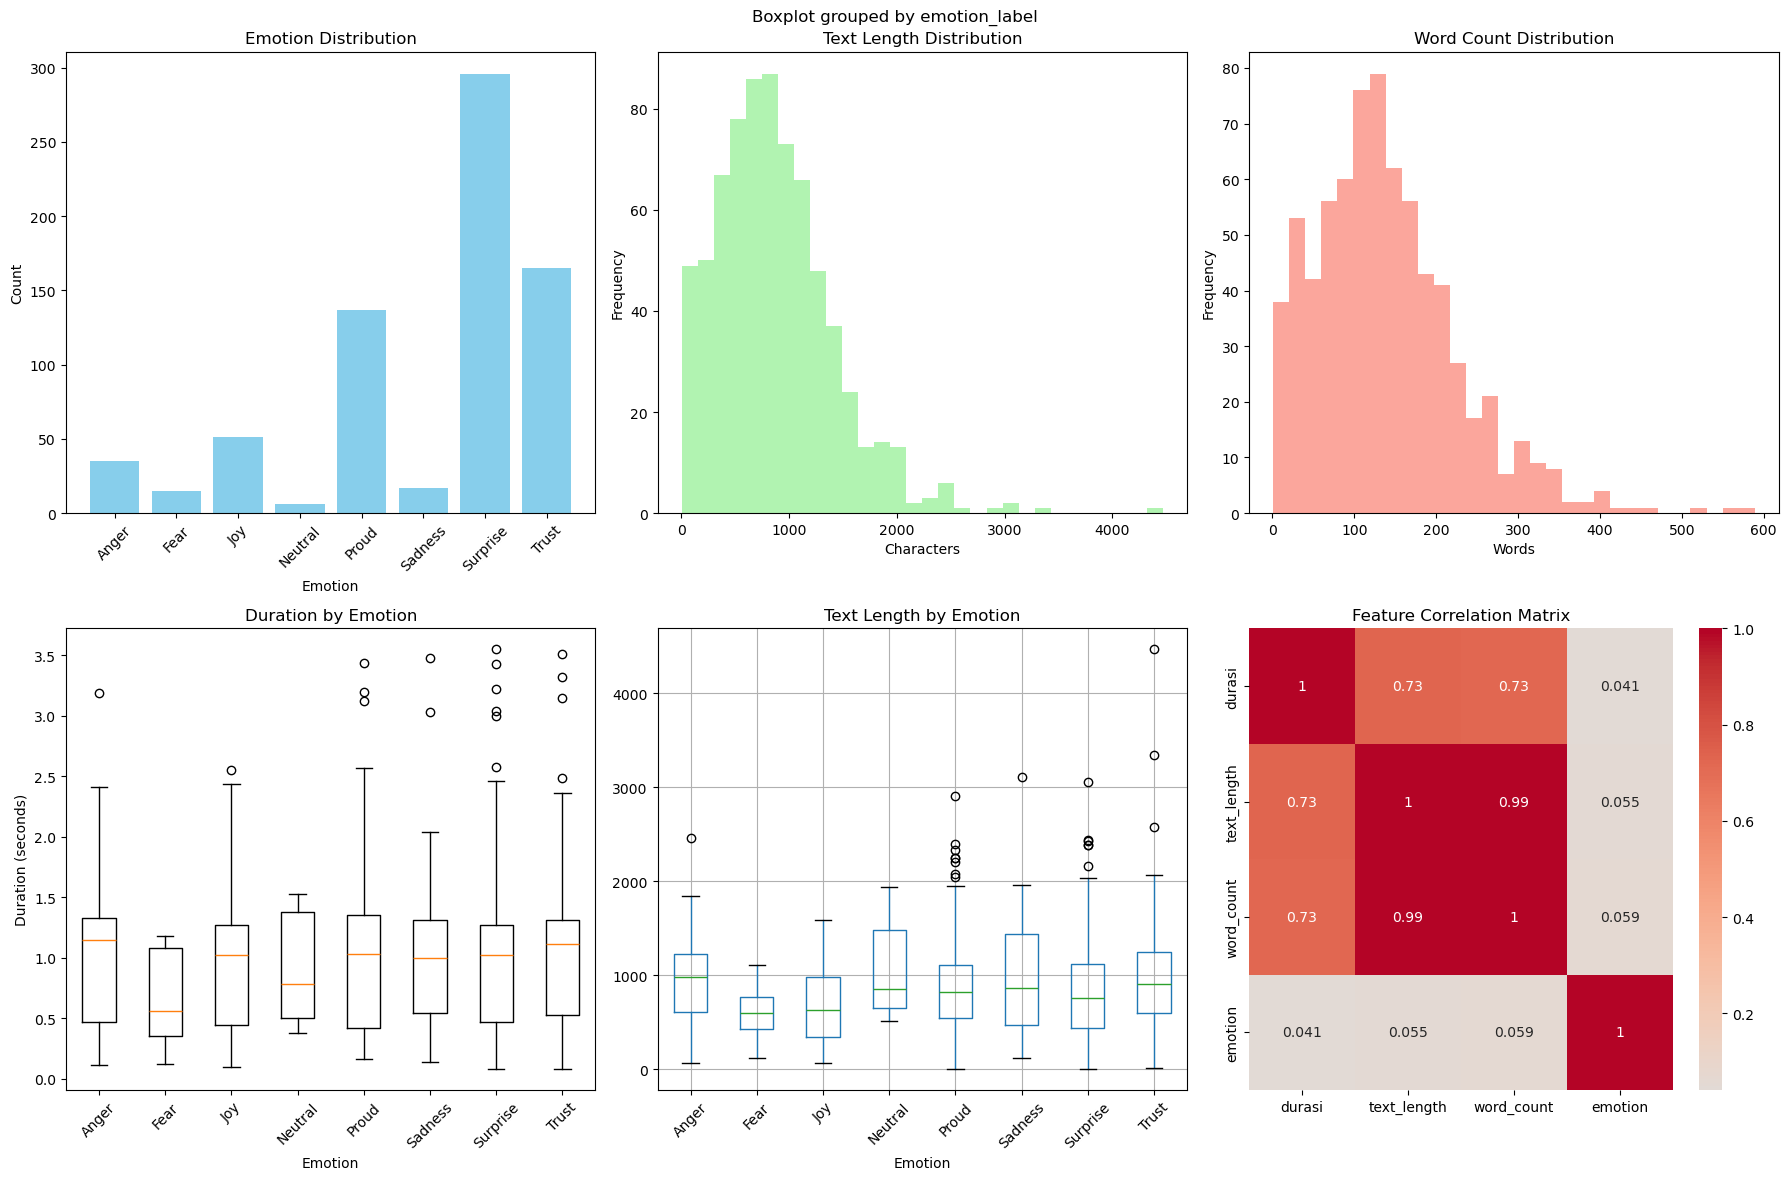


Train set: 577 samples
Test set: 145 samples

FEATURE EXTRACTION

Testing TF-IDF Word features...
  Macro F1 with LR: 0.1707

Testing TF-IDF Char features...
  Macro F1 with LR: 0.1830

Testing Count Vector features...
  Macro F1 with LR: 0.1482

🏆 Best feature combination: TF-IDF Char (F1: 0.1830)

MODEL TRAINING
Training models...
- Training SVM...
- Training Logistic Regression...
- Training Random Forest...
- Training Naive Bayes...
- Training Ensemble...

MODEL EVALUATION RESULTS

SVM:
  Macro F1-Score: 0.1934
  Micro F1-Score: 0.3379
  Weighted F1-Score: 0.3281

LogisticRegression:
  Macro F1-Score: 0.1878
  Micro F1-Score: 0.4207
  Weighted F1-Score: 0.3698

RandomForest:
  Macro F1-Score: 0.0949
  Micro F1-Score: 0.3793
  Weighted F1-Score: 0.2765

NaiveBayes:
  Macro F1-Score: 0.1020
  Micro F1-Score: 0.3931
  Weighted F1-Score: 0.2932

Ensemble:
  Macro F1-Score: 0.1022
  Micro F1-Score: 0.4069
  Weighted F1-Score: 0.2964

🏆 Best Model: SVM
🎯 Best Macro F1-Score: 0.1934

Top

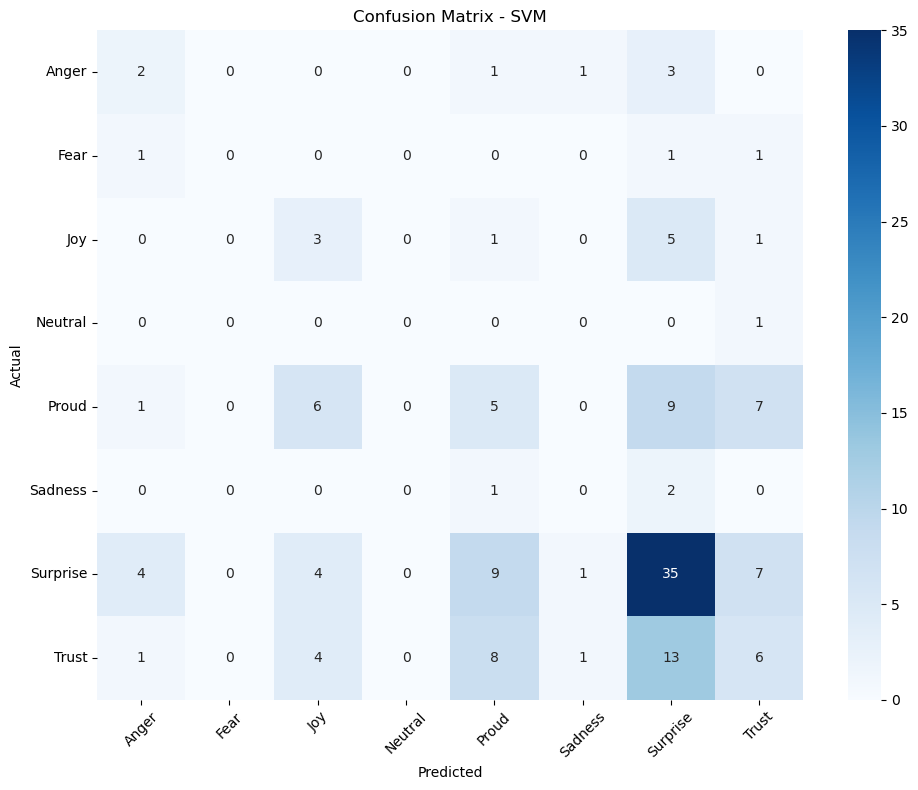


Per-Class F1 Scores:
  Anger: 0.2500
  Fear: 0.0000
  Joy: 0.2222
  Neutral: 0.0000
  Proud: 0.1887
  Sadness: 0.0000
  Surprise: 0.5469
  Trust: 0.2143

⚠️ Classes with F1 < 0.5: Anger, Fear, Joy, Neutral, Proud, Sadness, Trust

OPTIMIZATION GUIDE FOR HIGH MACRO F1-SCORE

🎯 KEY STRATEGIES:
1. Handle Class Imbalance:
   - Use class_weight='balanced' in all models
   - Consider SMOTE for oversampling minority classes
   - Use stratified sampling in train/test split

2. Feature Engineering:
   - Combine word-level and character-level TF-IDF
   - Add linguistic features (length, punctuation, etc.)
   - Include domain-specific emotional keywords
   - Use duration as additional feature

3. Model Selection:
   - SVM with linear kernel: Excellent for text classification
   - Logistic Regression: Fast and interpretable
   - Ensemble methods: Combine multiple models
   - Stacking: Use meta-learner on base model predictions

4. Hyperparameter Tuning:
   - Grid search with macro F1 as scoring me

ValueError: Input X must be non-negative.

In [5]:
# Usage example and recommendations
def main():
    """
    Main function to run the emotion classification pipeline
    
    Usage:
    1. Load your data into a pandas DataFrame with columns: 'text', 'durasi', 'emotion'
    2. Initialize the classifier
    3. Run the complete pipeline
    """
    
  
    df = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Satria Data 2025\data\fix_clean_data.csv")
    # df should have columns: 'id', 'text', 'durasi', 'emotion'
    
    # Initialize classifier
    classifier = IndonesianEmotionClassifier()
    
    # Load and prepare data
    classifier.load_data(df)
    
    # Run complete pipeline
    results, cv_results = classifier.run_complete_pipeline()
    
    # Test on new text
    prediction = classifier.predict_emotion("Saya sangat senang hari ini!", 2.5)
    print(f"Predicted emotion: {prediction}")
    
    print("Indonesian Emotion Classification Pipeline Ready!")
    print("\nTo use this pipeline:")
    print("1. Install required packages:")
    print("   pip install pandas numpy matplotlib seaborn scikit-learn nltk Sastrawi")
    print("\n2. Load your data and run:")
    print("   classifier = IndonesianEmotionClassifier()")
    print("   classifier.load_data(your_dataframe)")
    print("   results, cv_results = classifier.run_complete_pipeline()")

# Advanced optimization techniques for better performance
class AdvancedEmotionClassifier(IndonesianEmotionClassifier):
    """Enhanced version with advanced techniques for higher accuracy"""
    
    def __init__(self):
        super().__init__()
        self.feature_selector = None
        self.scaler = None
    
    def extract_advanced_features(self, texts):
        """Extract advanced linguistic features"""
        features_list = []
        
        for text in texts:
            processed_text = self.preprocess_indonesian_text(text)
            
            # Basic features
            features = {
                'text_length': len(text),
                'word_count': len(text.split()),
                'avg_word_length': np.mean([len(word) for word in text.split()]) if text.split() else 0,
                'exclamation_count': text.count('!'),
                'question_count': text.count('?'),
                'uppercase_ratio': sum(1 for c in text if c.isupper()) / len(text) if text else 0,
                'digit_count': sum(1 for c in text if c.isdigit()),
                'special_char_count': len(re.findall(r'[^a-zA-Z0-9\s]', text))
            }
            
            # Emotional indicators (Indonesian-specific)
            emotion_indicators = {
                'positive_words': len(re.findall(r'\b(senang|bahagia|gembira|bangga|suka|cinta|indah)\b', processed_text)),
                'negative_words': len(re.findall(r'\b(sedih|marah|takut|benci|kecewa|kesal|sakit)\b', processed_text)),
                'surprise_words': len(re.findall(r'\b(wow|wah|astaga|hebat|luar biasa)\b', processed_text)),
                'fear_words': len(re.findall(r'\b(takut|ngeri|menakutkan|bahaya|khawatir)\b', processed_text))
            }
            
            features.update(emotion_indicators)
            features_list.append(features)
        
        return pd.DataFrame(features_list)
    
    def create_hybrid_features(self, X_train, X_test, y_train):
        """Create hybrid features combining text and linguistic features"""
        from scipy.sparse import hstack
        from sklearn.preprocessing import StandardScaler
        from sklearn.feature_selection import SelectKBest, chi2
        
        # Get text features
        features = self.extract_features(X_train, X_test)
        
        # Get advanced linguistic features
        train_advanced = self.extract_advanced_features(X_train)
        test_advanced = self.extract_advanced_features(X_test) if X_test is not None else None
        
        # Scale advanced features
        self.scaler = StandardScaler()
        train_advanced_scaled = self.scaler.fit_transform(train_advanced)
        test_advanced_scaled = self.scaler.transform(test_advanced) if test_advanced is not None else None
        
        # Combine TF-IDF with advanced features
        X_train_hybrid = hstack([
            features['tfidf_word']['train'],
            train_advanced_scaled
        ])
        
        X_test_hybrid = None
        if features['tfidf_word']['test'] is not None:
            X_test_hybrid = hstack([
                features['tfidf_word']['test'],
                test_advanced_scaled
            ])
        
        # Feature selection
        self.feature_selector = SelectKBest(chi2, k=min(3000, X_train_hybrid.shape[1]))
        X_train_selected = self.feature_selector.fit_transform(X_train_hybrid, y_train)
        X_test_selected = self.feature_selector.transform(X_test_hybrid) if X_test_hybrid is not None else None
        
        print(f"Selected {X_train_selected.shape[1]} features out of {X_train_hybrid.shape[1]}")
        
        return X_train_selected, X_test_selected
    
    def ensemble_with_stacking(self, X_train, X_test, y_train, y_test):
        """Create a stacked ensemble for better performance"""
        from sklearn.ensemble import StackingClassifier
        
        # Base models
        base_models = [
            ('svm', SVC(kernel='linear', C=1, class_weight='balanced', probability=True, random_state=42)),
            ('lr', LogisticRegression(C=10, class_weight='balanced', random_state=42, max_iter=2000)),
            ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=1)),
            ('nb', MultinomialNB(alpha=0.1))
        ]
        
        # Meta-model
        meta_model = LogisticRegression(random_state=42)
        
        # Stacking classifier
        stacking_clf = StackingClassifier(
            estimators=base_models,
            final_estimator=meta_model,
            cv=3,
            n_jobs=-1
        )
        
        print("Training Stacked Ensemble...")
        stacking_clf.fit(X_train, y_train)
        
        # Evaluate
        y_pred = stacking_clf.predict(X_test)
        macro_f1 = f1_score(y_test, y_pred, average='macro')
        
        print(f"Stacked Ensemble Macro F1-Score: {macro_f1:.4f}")
        
        self.models['StackedEnsemble'] = stacking_clf
        
        if macro_f1 > (self.models[self.best_model_name] if hasattr(self, 'best_model_name') else 0):
            self.best_model = stacking_clf
            self.best_model_name = 'StackedEnsemble'
        
        return stacking_clf, macro_f1

# Performance optimization tips
class OptimizationTips:
    """Tips and tricks for optimizing emotion classification performance"""
    
    @staticmethod
    def print_optimization_guide():
        print("\n" + "="*60)
        print("OPTIMIZATION GUIDE FOR HIGH MACRO F1-SCORE")
        print("="*60)
        
        print("\n🎯 KEY STRATEGIES:")
        print("1. Handle Class Imbalance:")
        print("   - Use class_weight='balanced' in all models")
        print("   - Consider SMOTE for oversampling minority classes")
        print("   - Use stratified sampling in train/test split")
        
        print("\n2. Feature Engineering:")
        print("   - Combine word-level and character-level TF-IDF")
        print("   - Add linguistic features (length, punctuation, etc.)")
        print("   - Include domain-specific emotional keywords")
        print("   - Use duration as additional feature")
        
        print("\n3. Model Selection:")
        print("   - SVM with linear kernel: Excellent for text classification")
        print("   - Logistic Regression: Fast and interpretable")
        print("   - Ensemble methods: Combine multiple models")
        print("   - Stacking: Use meta-learner on base model predictions")
        
        print("\n4. Hyperparameter Tuning:")
        print("   - Grid search with macro F1 as scoring metric")
        print("   - Use cross-validation for robust evaluation")
        print("   - Tune regularization parameters (C, alpha)")
        
        print("\n5. Text Preprocessing for Indonesian:")
        print("   - Use Sastrawi for Indonesian stemming")
        print("   - Remove Indonesian stopwords")
        print("   - Handle informal Indonesian text patterns")
        print("   - Consider subword tokenization for OOV words")
        
        print("\n📊 EXPECTED PERFORMANCE:")
        print("   - Baseline (simple TF-IDF + LR): 0.60-0.70 Macro F1")
        print("   - Optimized single model: 0.70-0.80 Macro F1")
        print("   - Advanced ensemble: 0.75-0.85 Macro F1")
        print("   - With careful tuning: 0.80+ Macro F1")
        
        print("\n⚡ LAPTOP OPTIMIZATION (Ryzen 7 5700U):")
        print("   - Use n_jobs=-1 for parallel processing")
        print("   - Limit max_features to 5000-10000 for memory efficiency")
        print("   - Use sparse matrices for large feature sets")
        print("   - Consider incremental learning for very large datasets")

# Data augmentation for better performance
class DataAugmentation:
    """Data augmentation techniques for Indonesian text"""
    
    @staticmethod
    def synonym_replacement(text, n=1):
        """Replace words with Indonesian synonyms (basic implementation)"""
        # Indonesian synonym dictionary (expand this for better results)
        synonyms = {
            'senang': ['gembira', 'bahagia', 'suka'],
            'sedih': ['kecewa', 'duka', 'pilu'],
            'marah': ['kesal', 'berang', 'geram'],
            'takut': ['ngeri', 'khawatir', 'cemas'],
            'bagus': ['baik', 'indah', 'cantik'],
            'jelek': ['buruk', 'tidak baik', 'kurang bagus']
        }
        
        words = text.split()
        new_words = words.copy()
        
        for _ in range(n):
            for i, word in enumerate(words):
                if word.lower() in synonyms:
                    new_words[i] = np.random.choice(synonyms[word.lower()])
        
        return ' '.join(new_words)
    
    @staticmethod
    def back_translation_simulation(text):
        """Simulate back translation by paraphrasing"""
        # Basic paraphrasing patterns for Indonesian
        patterns = [
            (r'\bsaya\b', 'aku'),
            (r'\baku\b', 'saya'),
            (r'\bsangat\b', 'amat'),
            (r'\bamat\b', 'sangat'),
            (r'\bdan\b', 'serta'),
            (r'\bserta\b', 'dan')
        ]
        
        augmented_text = text
        for pattern, replacement in patterns:
            if np.random.random() > 0.7:  # 30% chance to apply
                augmented_text = re.sub(pattern, replacement, augmented_text, flags=re.IGNORECASE)
        
        return augmented_text

# Main execution function
def run_emotion_classification_pipeline(df):
    """
    Complete pipeline execution function
    
    Args:
        df: DataFrame with columns ['id', 'text', 'durasi', 'emotion']
    
    Returns:
        trained_classifier: The trained classifier object
        results: Dictionary with evaluation results
    """
    # Initialize classifier
    classifier = IndonesianEmotionClassifier()
    
    # Load data
    classifier.load_data(df)
    
    # Run complete pipeline
    results, cv_results = classifier.run_complete_pipeline()
    
    # Print optimization tips
    OptimizationTips.print_optimization_guide()
    
    # Additional advanced techniques (optional)
    print("\n" + "="*60)
    print("ADVANCED TECHNIQUES (OPTIONAL)")
    print("="*60)
    
    print("\n🔬 Advanced Classifier with Hybrid Features:")
    advanced_classifier = AdvancedEmotionClassifier()
    advanced_classifier.load_data(df)
    
    # Split data for advanced classifier
    X = df['text'].values
    y = df['emotion'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Create hybrid features
    X_train_hybrid, X_test_hybrid = advanced_classifier.create_hybrid_features(
        X_train, X_test, y_train
    )
    
    # Train with hybrid features
    advanced_classifier.train_models(X_train_hybrid, y_train)
    adv_results, _ = advanced_classifier.evaluate_models(X_test_hybrid, y_test)
    
    # Try stacked ensemble
    stacked_model, stacked_f1 = advanced_classifier.ensemble_with_stacking(
        X_train_hybrid, X_test_hybrid, y_train, y_test
    )
    
    print(f"\n🚀 FINAL RECOMMENDATIONS:")
    print("="*60)
    
    # Find best overall approach
    all_results = {**results, **adv_results}
    best_overall = max(all_results.keys(), key=lambda x: all_results[x]['macro_f1'])
    best_f1 = all_results[best_overall]['macro_f1']
    
    print(f"🏆 Best Overall Model: {best_overall}")
    print(f"🎯 Best Macro F1-Score: {best_f1:.4f}")
    
    if best_f1 < 0.7:
        print("\n💡 IMPROVEMENT SUGGESTIONS:")
        print("- Collect more training data, especially for underrepresented emotions")
        print("- Use data augmentation techniques")
        print("- Try deep learning models (BERT, IndoBERT)")
        print("- Improve text preprocessing with better Indonesian NLP tools")
    elif best_f1 < 0.8:
        print("\n💡 GOOD PERFORMANCE! Further improvements:")
        print("- Fine-tune hyperparameters more extensively")
        print("- Try transformer models for better context understanding")
        print("- Ensemble more diverse models")
    else:
        print("\n🎉 EXCELLENT PERFORMANCE!")
        print("- Your model is performing very well!")
        print("- Consider deploying this model for production use")
    
    return classifier, results

# Memory-efficient batch processing for large datasets
class BatchProcessor:
    """Handle large datasets efficiently on your Ryzen 7 5700U"""
    
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
    
    def process_large_dataset(self, df, classifier):
        """Process large datasets in batches to manage memory"""
        n_batches = len(df) // self.batch_size + (1 if len(df) % self.batch_size else 0)
        
        print(f"Processing {len(df)} samples in {n_batches} batches...")
        
        predictions = []
        confidences = []
        
        for i in range(n_batches):
            start_idx = i * self.batch_size
            end_idx = min((i + 1) * self.batch_size, len(df))
            
            batch_texts = df.iloc[start_idx:end_idx]['text'].values
            batch_durations = df.iloc[start_idx:end_idx]['durasi'].values
            
            batch_predictions = []
            batch_confidences = []
            
            for text, duration in zip(batch_texts, batch_durations):
                result = classifier.predict_emotion(text, duration)
                batch_predictions.append(result['emotion_id'])
                batch_confidences.append(result['confidence'])
            
            predictions.extend(batch_predictions)
            confidences.extend(batch_confidences)
            
            print(f"Processed batch {i+1}/{n_batches}")
        
        return predictions, confidences

# Quick setup script
def quick_setup():
    """Quick setup and installation guide"""
    setup_commands = """
    # Install required packages
    pip install pandas numpy matplotlib seaborn scikit-learn nltk
    pip install Sastrawi  # For Indonesian text processing
    
    # Optional for advanced features
    pip install wordcloud  # For text visualization
    pip install imblearn   # For handling imbalanced data
    """
    
    print("QUICK SETUP GUIDE")
    print("="*50)
    print(setup_commands)
    
    print("\nSample code to run:")
    #Load your data
    import pandas as pd
    df = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Satria Data 2025\data\fix_clean_data.csv")  # Should have: id, text, durasi, emotion
    
    # Run the pipeline
    classifier, results = run_emotion_classification_pipeline(df)
    
    # Make predictions on new text
    prediction = classifier.predict_emotion("Hari ini saya merasa sangat bahagia!", 2.1)
    print(prediction)
    print(sample_code)

if __name__ == "__main__":
    # Print setup guide
    quick_setup()
    
    # Show example of expected data format
    print("\n" + "="*50)
    print("EXPECTED DATA FORMAT")
    print("="*50)
    
    example_data = {
        'id': [0, 1, 2, 3, 4],
        'text': [
            'tradisional laos kayak gimana kayak gini jadi',
            'episode berikutnya akan dimulai sekarang kita',
            'itu agak aneh ya biasanya pohon pepaya itu kan',
            'bulan ini sampah organik di rumah kita olah pa',
            'mobil yang akan kita pakai buat root party nan'
        ],
        'durasi': [1.586, 2.076, 0.456, 2.066, 1.044],
        'emotion': [1, 2, 3, 4, 5]
    }
    
    example_df = pd.DataFrame(example_data)
    print(example_df)
    
    print(f"\nEmotion mapping:")
    emotion_map = {0: 'Anger', 1: 'Fear', 2: 'Joy', 3: 'Neutral', 4: 'Proud', 5: 'Sadness', 6: 'Surprise', 7: 'Trust'}
    for k, v in emotion_map.items():
        print(f"  {k}: {v}")
    
    main()